In [1]:
!bash -lc 'module load Miniforge3/24.1.2-0 && source $EBROOTMINIFORGE3/bin/activate && conda activate hycom-cice'
import xarray as xr

The following modules were not unloaded:
  (Use "module --force purge" to unload all):

  1) StdEnv


In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import TwoSlopeNorm

def ArcticMap():

    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw={"projection": ccrs.NorthPolarStereo(central_longitude=0.0)},
    )

    ax.set_extent([-180, 180, 48, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor=cfeature.COLORS["land"], edgecolor="grey", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="grey", linewidth=0.4, zorder=3)
    ax.gridlines()
      
    return fig, ax
    
def pcolormesh_curvilinear(lon, lat, data, ax=None, **kwargs):

    proj = ax.projection
    pxy = proj.transform_points(ccrs.PlateCarree(), lon, lat)
    px, py = pxy[:, :, 0], pxy[:, :, 1]
    invalid = ~np.isfinite(px) | ~np.isfinite(py)
    px = np.where(invalid, 0.0, px)
    py = np.where(invalid, 0.0, py)
    data = np.where(invalid, np.nan, data)
    return ax.pcolormesh(px, py, data, **kwargs)


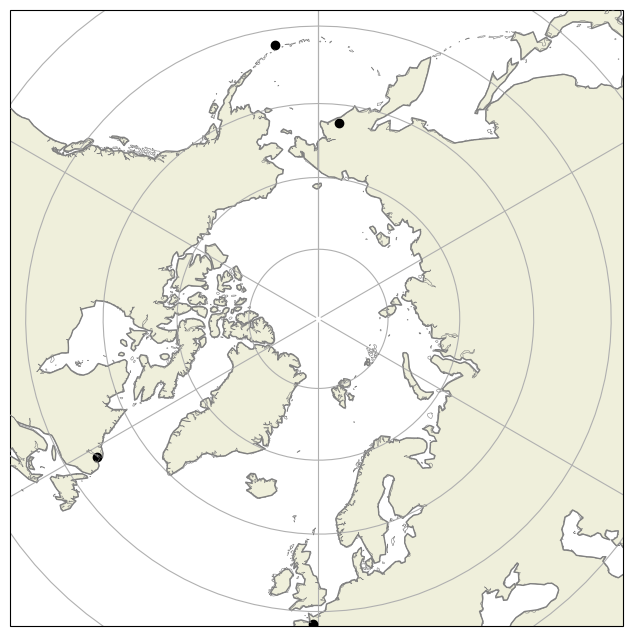

In [34]:
POINTS = {
    "Atlantic West": {"lat": 54.0, "lon": -58.0},
    "Atlantic East": {"lat": 48.5, "lon": -1.0},
    "Pacific West": {"lat": 62.5, "lon": 174.0},
    "Pacific East": {"lat": 52.0, "lon": -171.0},
}

fig, ax = ArcticMap()

for name, p in POINTS.items():
    plt.plot(p["lon"],p["lat"],"ko",transform=ccrs.PlateCarree())